In [4]:
import pandas as pd
import tsfeatures as tsf
import matplotlib.pyplot as plt
import seaborn as sns
from utilsforecast.plotting import plot_series

## chapter 5.1

<div dir="rtl" align="right">

**مدل‌های محک یا پایه (Benchmark methods):** روش‌های خیلی ساده‌ای (مثل این‌که بگیم مقدار فردا برابر است با مقدار امروز) که مثل خط‌کش عمل می‌کنند. هر مدل خفنی که بعداً بسازی، باید اول ثابت کنه از این روش‌های ساده بهتره!

**بررسی عملکرد مدل (Diagnostic checks):** آیا مدلی که ساختیم تمام الگوها و اطلاعات داده رو کشیده بیرون، یا هنوز نکاتی هست که مدل نتونسته یاد بگیره؟ (بررسی پسماندها یا Residuals).

**بازه اطمینان پیش‌بینی (Prediction intervals):** به جای این‌که فقط یک عدد قطعی بگیم (مثلاً «فردا فروش ۱۰۰ تاست»)، یک بازه مشخص کنیم («با احتمال ۹۵٪ بین ۹۰ تا ۱۱۰ تاست») تا عدم قطعیت آینده رو نشون بدیم.

**ارزیابی دقت (Evaluating accuracy):** استفاده از معیارهای استاندارد (مثل MAE یا RMSE) برای این‌که بفهمیم خطای کارمون چقدر بوده.


</div>

**Data preparation (tidy)**

The first step in forecasting is to prepare data in the correct format. This process may involve loading in data, identifying missing values, filtering the time series, and other pre-processing tasks. The functionality provided by pandas substantially simplifies this step.

Many models have different data requirements; some require the series to be in time order, others require no missing values. Checking your data is an essential step to understanding its features and should always be done before models are estimated.

In [5]:
gdp_df = (pd.read_csv("C:\\Users\\dell\\forecasting\\global_economy.csv", parse_dates=["ds"])[["unique_id", "ds", "GDP", "Population"]]
    .assign( GDP=lambda x: x["GDP"].interpolate(), Population=lambda x: x["Population"].interpolate(), y=lambda x: x["GDP"] / x["Population"])
)

**Plot the data (visualise)**

As we have seen in Chapter 2, visualisation is an essential step in understanding the data. Looking at your data allows you to identify common patterns, and subsequently specify an appropriate model.

In [6]:
gdp_df.head()

,unique_id,ds,GDP,Population,y
0,Afghanistan,1960-01-01,5.377778e+08,8996351.0,59.777327
1,Afghanistan,1961-01-01,5.488889e+08,9166764.0,59.878153
2,Afghanistan,1962-01-01,5.466667e+08,9345868.0,58.492874
3,Afghanistan,1963-01-01,7.511112e+08,9533954.0,78.782758
4,Afghanistan,1964-01-01,8.000000e+08,9731361.0,82.208444


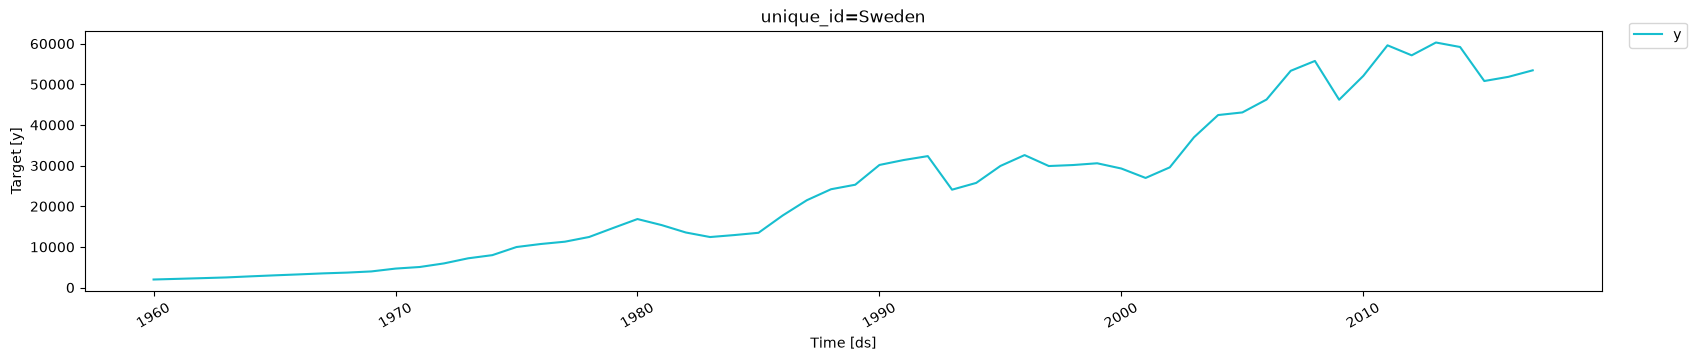

In [7]:
plot_series(gdp_df, ids=["Sweden"])

**Define a model (specify)**

Specifying an appropriate model for the data is essential for producing appropriate forecasts.


**Train the model (estimate)**

Once an appropriate model is specified, we next train the model on some data

In [8]:
sweden_df = gdp_df.loc[lambda x : x["unique_id"] == "Sweden"][["unique_id" , "ds" , "y"]]

<div dir="rtl" align="right">

خروجی (train_features, valid_features):
تابع داده‌ها را بر اساس افق پیش‌بینی تقسیم (Split) می‌کند: ۳ سال آخر را در valid_features (مجموعه اعتبارسنجی/تست) قرار می‌دهد و مابقی گذشته را در train_features (مجموعه آموزش).
ستون ویژگی روند (trend) به هر دو دیتافریم اضافه می‌شود تا در آموزش و تست به عنوان متغیر مستقل (رگرسور) استفاده شود.

</div>

In [9]:
from fpppy.models import LinearRegression
from statsforecast import StatsForecast
from statsforecast.models import SklearnModel
from utilsforecast.feature_engineering import pipeline, trend


train_features, valid_features = pipeline(sweden_df, features=[trend], freq="Y", h=3) # freq = بسامد یا فرکانس داده در اینجا مخخفف سالانه هست
# h = افق پیش بینی و در اینجا 3 گام زمانی به معنای 3 سال آینده هست

trend_model = SklearnModel(LinearRegression())
#این کلاس یک واسط است که مدل‌های استاندارد را با ابزارهای سری زمانی سازگار می‌کند
#تا بتوان آن‌ها را مستقیماً داخل پایپ‌لاین‌های پیش‌بینی سری زمانی اجرا کرد

sf = StatsForecast(models=[trend_model], freq="Y") # models =  لیستی از مدل‌هایی که می‌خواهیم روی داده‌ها اعمال کنیم را مشخص می‌کند
#StatsForecast: شیء اصلی برای مدیریت، برازش و پیش‌بینی سری‌های زمانی است


sf.fit(df=train_features)
#مدل رابطه خطی بین متغیر هدف و متغیر روند را روی بخش آموزش یاد می‌گیرد
# رابطه ی بین y , trend

StatsForecast(models=[LinearRegression])

**Check model performance (evaluate)**

Once a model has been fitted, it is important to check how well it has performed on the data. There are several diagnostic tools available to check model behaviour, and also accuracy measures that allow one model to be compared against another

**Produce forecasts (forecast)**

With an appropriate model specified, estimated and checked, it is time to produce the forecasts using the `forecast()` method. The easiest way to use this function is by specifying the number of future observations to forecast.

In [10]:
fcasts = sf.predict(h=3, X_df=valid_features) 
# X_df=valid_features: داده‌های متغیرهای مستقل/کمکی برای آینده رو به مدل میده.
# چون مدل ما خطی است و روی ویژگی ترند آموزش دیده برای سال‌های آینده هم مقدار ترند رو ازش می‌خونه
#خروجی یک دیتافریم خواهد بود شامل ستون‌های دی اس و یونیک ایدی و ستونی به اسم مدلمون 
# (LinearRegression) که مقدار پیش‌بینی نقطه‌ای داخلشه

# We are using a LinearRegression wrapper that provides
# the following method for calculating prediction intervals
model = sf.fitted_[0][0].model_["model"]

fcasts = model.add_prediction_intervals(fcasts, valid_features.rename(columns={"trend": "x1"}))

<div dir="rtl" align="right">


**sf.fitted_[0][0].model_["model"]:**

در ساختار Nixtla / StatsForecast، مدل‌های آموزش‌دیده روی سری‌های مختلف داخل ساختاری مثل ماتریس/لیست دو‌بعدی ذخیره می‌شن (fitted_).

با این ایندکس‌ها، مستقیماً به شیء درونی مدل رگرسیون خطی که فیت شده دسترسی پیدا می‌کنیم.

در کامنت هم اشاره شده این یک wrapper خاص برای LinearRegression است که متد اختصاصی برای محاسبه بازه اطمینان بهش اضافه شده.


**valid_features.rename(columns={"trend": "x1"}):**

احتمالاً این wrapper انتظار داره متغیرهای مستقل آینده با نام‌های استاندارد مثل  باشن، پس ستون trend به x1 تغییر نام داده شده تا با فرمول رگرسیون هماهنگ بشه.


**model.add_prediction_intervals(...):**

متد اختصاصی این wrapper است که خطای استاندارد مدل و باقیمانده‌ها رو در نظر می‌گیره و ستون‌های سطوح اطمینان (معمولاً درصدهای پیش‌فرضی مثل ۸۰٪ و ۹۵٪، یعنی کران‌های بالا و پایین lo-80, hi-80, lo-95, hi-95) رو مستقیماً به جدول fcasts اضافه می‌کنه.



</div>

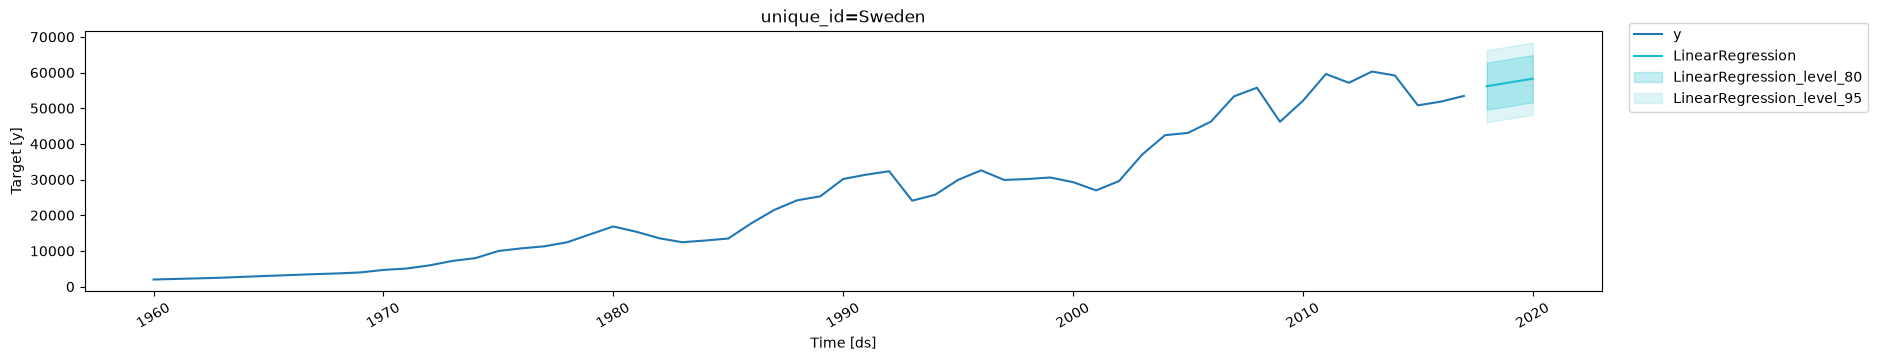

In [14]:
plot_series(sweden_df, fcasts, ids=["Sweden"], level=[80, 95])

## chapter 5.2

In [15]:
production_df = pd.read_csv("C:\\Users\\dell\\forecasting\\aus_production_formatted.csv",parse_dates=["ds"])

bricks_df = production_df.loc[lambda x: ((x["unique_id"] == "Bricks") & (x["ds"].between("1970", "2004-12")))].dropna()


**Mean method**

the forecasts of all future values are equal to the average (or “mean”) of the historical data. 
If we let the historical data be denoted by y1,…,yTy1​,…,yT​, then we can write the forecasts as 

$$\hat{y}_{T+h|T} = \bar{y} = \frac{y_1 + \dots + y_T}{T}$$


In [16]:
from statsforecast import StatsForecast
from statsforecast.models import HistoricAverage


avg_method = HistoricAverage()
sf = StatsForecast(models=[avg_method], freq="Q")

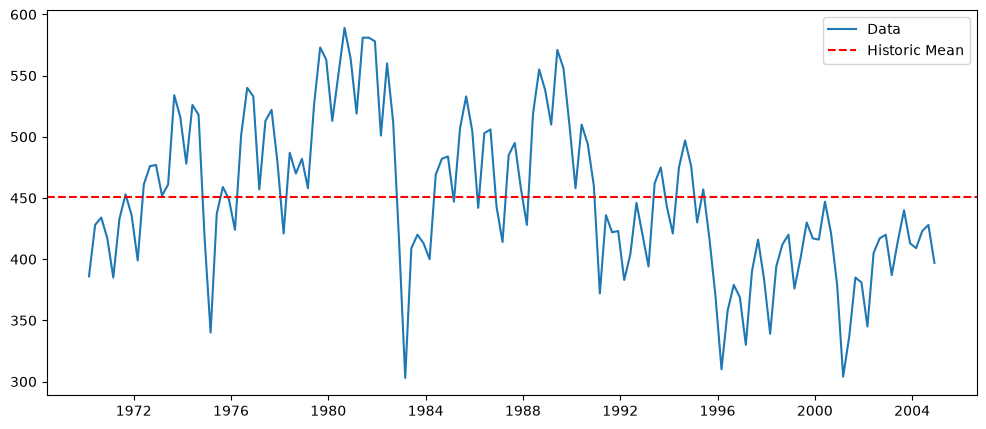

In [29]:
fig , ax = plt.subplots(figsize=(12, 5))

plt.plot(bricks_df['ds'], bricks_df['y'], label='Data')

plt.axhline(bricks_df['y'].mean(), color='red', linestyle='--', label='Historic Mean')

plt.legend()
plt.show()

**Naïve method**

For Naïve forecasts, we simply set all forecasts to be the value of the last observation. That is,

$$\hat{y}_{T+h|T} = y_t$$

This method works remarkably well for many economic and financial time series.

Because a Naïve forecast is optimal when data follow a random walk ,these are also called random walk forecasts.

In [30]:
from statsforecast.models import Naive

naive_method = Naive()
sf = StatsForecast(models=[naive_method], freq="Q")

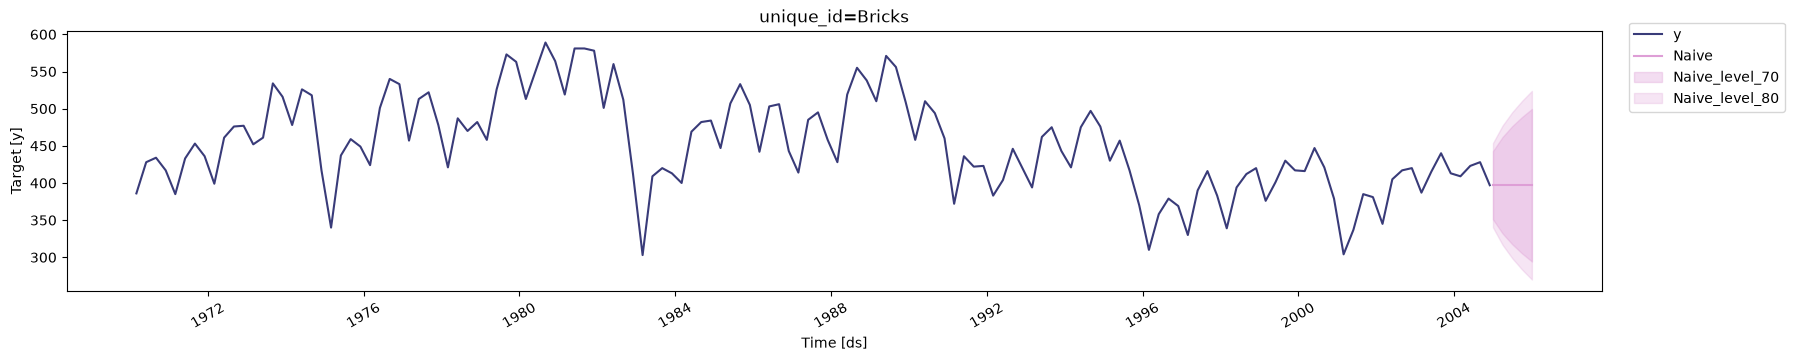

In [34]:
fcasts = sf.forecast(df=bricks_df, h =5 , level=[70,80])
sf.plot(bricks_df, fcasts, level=[70,80])

**Seasonal Naïve method**

A similar method is useful for highly seasonal data. In this case, we set each forecast to be equal to the last observed value from the same season.

Formally, the forecast for time T+h is written as:

$$\hat{y}_{T+h|T} = y_{T+h−m(k+1)}$$

where m= the seasonal period, and k is the integer part of (h−1)/m.

For example, with monthly data, the forecast for all future February values is equal to the last observed February value. With quarterly data, the forecast of all future Q2 values is equal to the last observed Q2 value.

In [ ]:
from statsforecast.models import SeasonalNaive

seasonal_naive_method = SeasonalNaive(4)
sf = StatsForecast(models=[seasonal_naive_method], freq="Q")

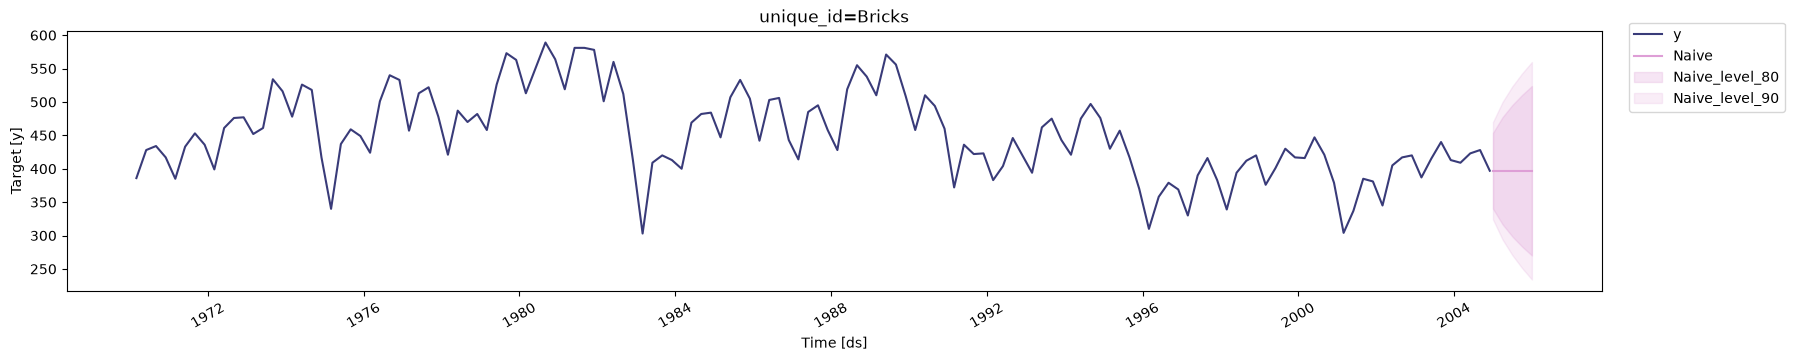

In [36]:
fcasts = sf.forecast(df=bricks_df, h = 5 , level=[80,90])
sf.plot(bricks_df, fcasts, level=[80,90])

**Drift method**

A variation on the Naïve method is to allow the forecasts to increase or decrease over time, where the amount of change over time (called the drift) is set to be the average change seen in the historical data. Thus, the forecast for time T+h is given by 

$$\hat{y}_{T+h|T} = y_T + \frac{h}{T-1} \sum_{t=2}^{T} (y_t - y_{t-1}) = y_T + h \left( \frac{y_T - y_1}{T-1} \right)$$

This is equivalent to drawing a line between the first and last observations, and extrapolating it into the future.

بیا آخرین مقدار  رو برداریم، اما بهش اجازه بدیم در طول زمان کم‌کم بالا یا پایین بره . به چه اندازه‌ای؟ به اندازه میانگین کل تغییراتی که تا امروز در تاریخچه دیدیم.

In [37]:
from statsforecast.models import RandomWalkWithDrift

drift_method = RandomWalkWithDrift()
sf = StatsForecast(models=[drift_method], freq="Q")  # Q = Quarterly

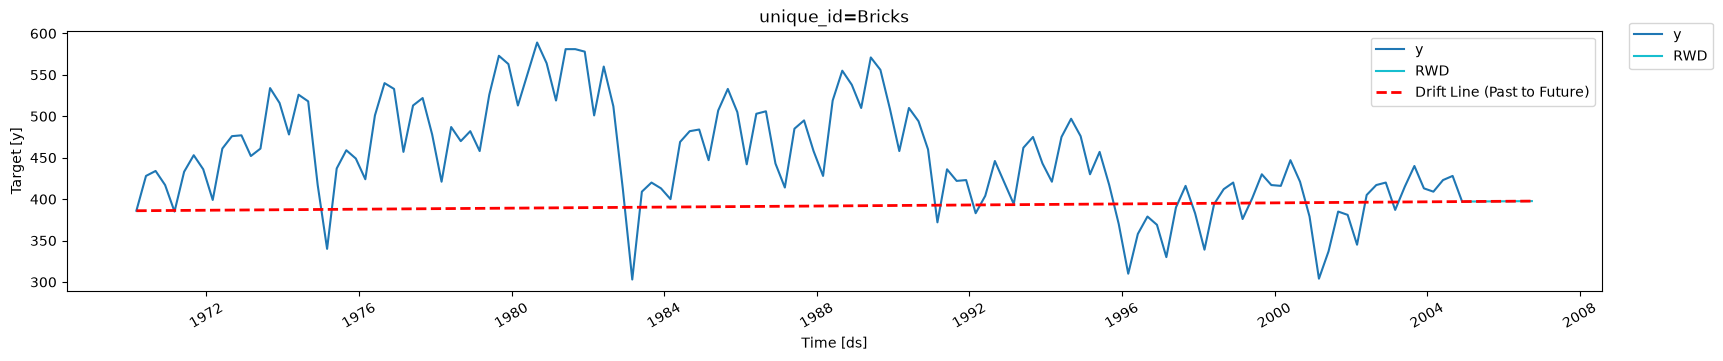

In [ ]:
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import RandomWalkWithDrift
from utilsforecast.plotting import plot_series

sf = StatsForecast(models=[RandomWalkWithDrift()], freq="Q")
sf.fit(bricks_df)
fcasts = sf.predict(h=8)
fig = plot_series(bricks_df, fcasts)
ax = fig.axes[0]

t_start = bricks_df["ds"].iloc[0]
y_start = bricks_df["y"].iloc[0]
t_end = fcasts["ds"].iloc[-1]
y_end = fcasts["RWD"].iloc[-1]

ax.plot([t_start, t_end], [y_start, y_end], color="red", linestyle="--", linewidth=2, label="Drift Line (Past to Future)")
ax.legend()
fig


**Example: Australian quarterly beer production**

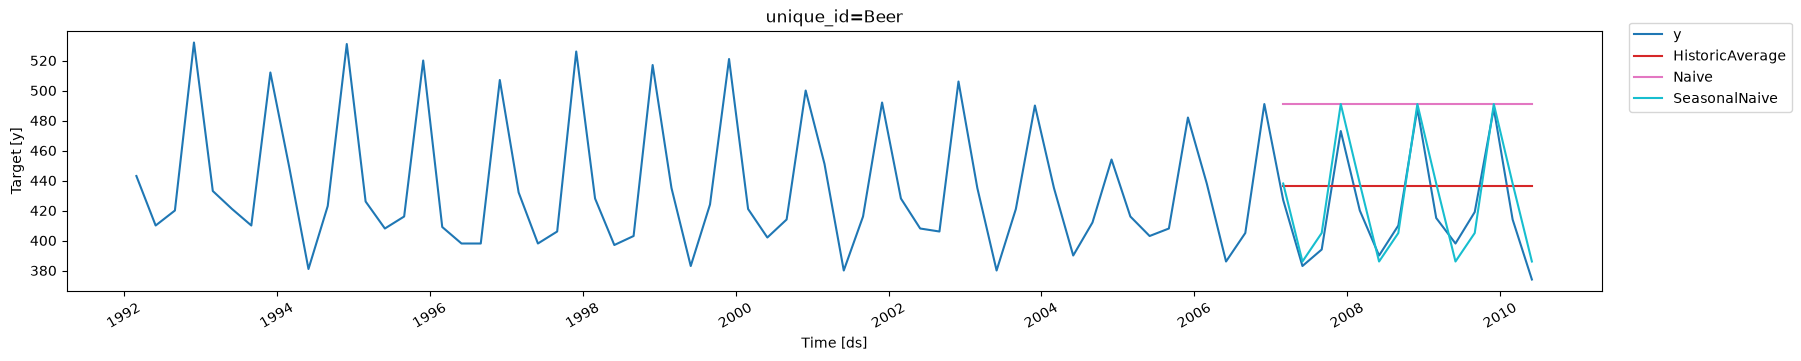

In [54]:
from statsforecast import StatsForecast
from statsforecast.models import HistoricAverage, Naive, SeasonalNaive

beers_df = production_df.loc[lambda x : (x["unique_id"] == "Beer") & (x["ds"].dt.year >= 1992)]

train = beers_df.loc[lambda x : x["ds"].dt.year < 2007].copy()
test = beers_df.loc[lambda x : x["ds"].dt.year >= 2007].copy()

avg_model = HistoricAverage()
naive_model = Naive()
seasonal_model = SeasonalNaive(4)

sf = StatsForecast(models=[avg_model, naive_model, seasonal_model],freq=pd.offsets.QuarterBegin(1))
sf.fit(train)

#چون هدف ما اینه که پیش‌بینی مدل‌ها رو با داده‌های واقعیِ آینده که نگه داشتیم (یعنی مجموعه‌ی تست) مقایسه کنیم، طول پیش‌بینی باید دقیقاً برابر با تعداد ردیف‌های تست باشه:
##  پیش‌بینی به اندازه طول داده‌های تست و اضافه کردن مقدار واقعی y
fcasts = sf.predict(h=14).assign(y=test["y"].to_numpy())

plot_series(train, fcasts)


<div dir="rtl" align="right">

**نکته‌ی مهم:** تفاوت Fitted Value با Forecast آینده در چیه؟

Forecast: نگاهش به آینده‌ی نامعلوم بیرون از مجموعه داده‌هاست (مثلاً افق 
ℎگام بعد).

Fitted Value: نگاهش به گذشته است؛ یعنی مدل روی تک‌تک داده‌های خودِ داده‌ی آموزشی (In-Sample) تست می‌کنه ببینه اگر قرار بود داده‌ی بعدی رو حدس بزنه، چی حدس می‌زد.


وقتی در زمان 𝑡 هستی، با داشتن تمام داده‌های قبل از آن یعنی (
𝑦
1
,
𝑦
2
,
…
,
𝑦
𝑡
−
1)، یک پیش‌بینی برای خود مقدارِ 
𝑦
𝑡انجام میدی.
به این پیش‌بینی «یک گام به جلو درون مجموعه‌ی داده‌ها» می‌گوییم Fitted Value (مقدار برازش‌شده).

---
**پسماندها (Residuals) چیستند؟**
به زبان خیلی خودمانی: «آنچه که مدل نتوانسته از داده‌ها بفهمد و جا انداخته است!»

پسماند برابر است با فاصله‌ی مقدار واقعی با مقداری که مدل برازش کرده:

</div>

$$e_{t} = y_{t} - \hat{y}_{t}$$

Actually, fitted values are often not true forecasts because any parameters involved in the forecasting method are estimated using all available observations in the time series, including future observations.




| مفهوم | تعریف | فرمول | نکته کلیدی |
| :--- | :--- | :---: | :--- |
| **Fitted Value ($\hat{y}_t$)** | پیش‌بینی یک گام به جلو برای مشاهدات گذشته درون داده‌های train | $\hat{y}_{t\|t-1}$ | اگر پارامتر مدل از کل داده‌ها گرفته بشه، True Forecast نیست. |
| **پسماند معمولی ($e_t$)** | تفاوت مقدار واقعی و مقدار برازش‌شده در مقیاس داده اصلی | $y_t - \hat{y}_t$ | اگر الگو یا چرخه‌ای در آن بماند، مدل ناقص است. |
| **پسماند نوآوری (Innov)** | پسماند در مقیاس تبدیل‌شده (مثل Log) | $w_t - \hat{w}_t$ | در صورت عدم استفاده از تبدیل، دقیقاً مساوی پسماند معمولی است. |
| **دستور در StatsForecast** | گرفتن مقادیر با سوییچ `fitted=True` | `sf.forecast_fitted_values()` | برای ارزیابی سلامت فرضیات مدل استفاده می‌شود. |




In [55]:
train = beers_df.loc[lambda x: x["ds"] < "2007"]
test = beers_df.loc[lambda x: x["ds"] >= "2007"]

avg_method = HistoricAverage()
sf = StatsForecast(models=[avg_method], freq="Q")
sf.forecast(h=14, df=train, fitted=True)
fitted_values = sf.forecast_fitted_values()
df = train.assign(fitted=fitted_values["HistoricAverage"].to_numpy(), resid=lambda x: x["y"] - x["fitted"], innov=lambda x: x["y"] - x["fitted"])
df.head()

,unique_id,ds,y,fitted,resid,innov
144,Beer,1992-03-01,443.0,436.45,6.55,6.55
145,Beer,1992-06-01,410.0,436.45,-26.45,-26.45
146,Beer,1992-09-01,420.0,436.45,-16.45,-16.45
147,Beer,1992-12-01,532.0,436.45,95.55,95.55
148,Beer,1993-03-01,433.0,436.45,-3.45,-3.45
